# Matched-gene analysis of 192-component spectra

This compact analysis filters the source table to **Mammalia** and uses the exact **COX1 + COX3 + CytB** intersection (expected $N=52$ species). It compares all 192 normalized context components, then focuses on the 16 flanking contexts of four heavy-strand transitions: `C>T`, `A>G`, `G>A`, and `T>C`.

Source labels are reverse-complemented **once as complete context labels**: the two flanks exchange positions and are complemented, and both central alleles are complemented. `Mut_raw` preserves the source label and `ContextOrientation` records the transformation. The positional analysis uses the same fixed human-rCRS DssH proxy as stage 4; it is a common gene-position scale, not a measured single-stranded duration in each mammal.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or this analysis folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        source = candidate / "1init_data" / "data" / "MutSpecVertebrates192.csv.gz"
        if source.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
ANALYSIS_DIR = ROOT / "5context192"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from context192_analysis import (
    CONTEXT192_ORDER,
    add_context_columns,
    annotate_context_qc,
    calculate_within_substitution_shares,
    orient_contexts_to_heavy_strand,
    plot_context192_bar_spectra,
    select_common_species_192,
    summarize_context_components,
    summarize_context_tsss_slopes,
    validate_matched_context192,
)

GENES = ("CO1", "CO3", "Cytb")
GENE_LABELS = {"CO1": "COX1", "CO3": "COX3", "Cytb": "CytB"}
SELECTED_SUBSTITUTIONS = ("C>T", "A>G", "G>A", "T>C")
BASES = ("A", "C", "G", "T")
CONTEXT_ORDER = tuple(f"{left}_{right}" for left in BASES for right in BASES)
CLASS_FILTER = "Mammalia"
EXPECTED_COHORT_SIZE = 52
N_BOOT = 2_000
RANDOM_STATE = 20260805
DATA_PATH = ROOT / "1init_data" / "data" / "MutSpecVertebrates192.csv.gz"
DATA_DIR = ANALYSIS_DIR / "data"
FIGURES_DIR = ANALYSIS_DIR / "figures"
for directory in (DATA_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# Fixed human-rCRS coordinates, repeated here to keep this stage runnable on its own.
MTDNA_LENGTH = 16_569
ORIL_START = 5_730
gene_metadata = pd.DataFrame(
    {
        "Gene": ["CO1", "CO3", "Cytb"],
        "display_gene": ["COX1", "COX3", "CytB"],
        "arc_position": ["beginning", "middle", "end"],
        "rCRS_start": [5904, 9207, 14747],
        "rCRS_end": [7445, 9990, 15887],
    }
)
gene_metadata["rCRS_midpoint"] = (
    gene_metadata["rCRS_start"] + gene_metadata["rCRS_end"]
) / 2
gene_metadata["dssh_proxy"] = (
    2 * (gene_metadata["rCRS_midpoint"] - ORIL_START) / MTDNA_LENGTH
)
gene_metadata.to_csv(DATA_DIR / "gene_tsss_proxy.csv", index=False)
display(gene_metadata.round({"rCRS_midpoint": 1, "dssh_proxy": 3}))

,Gene,display_gene,arc_position,rCRS_start,rCRS_end,rCRS_midpoint,dssh_proxy
0,CO1,COX1,beginning,5904,7445,6674.5,0.114
1,CO3,COX3,middle,9207,9990,9598.5,0.467
2,Cytb,CytB,end,14747,15887,15317.0,1.157


In [3]:
spectra = pd.read_csv(DATA_PATH)
analysis_spectra = spectra.loc[spectra["Class"].eq(CLASS_FILTER)].copy()
if analysis_spectra.empty or set(analysis_spectra["Class"]) != {CLASS_FILTER}:
    raise ValueError(f"Expected a non-empty {CLASS_FILTER}-only dataset")
matched_raw, common_species = select_common_species_192(analysis_spectra, GENES)
raw_info = validate_matched_context192(matched_raw, genes=GENES)
assert len(common_species) == EXPECTED_COHORT_SIZE, (
    f"Expected {EXPECTED_COHORT_SIZE} matched species, found {len(common_species)}"
)

# This is the only orientation call in the analysis. The helper marks its output
# and refuses to orient an already-marked heavy-strand table a second time.
matched_heavy = orient_contexts_to_heavy_strand(
    matched_raw, keep_original=True, original_col="Mut_raw"
)
matched_info = validate_matched_context192(matched_heavy, genes=GENES)
assert set(matched_heavy["Mut"]) == set(CONTEXT192_ORDER)
matched = add_context_columns(annotate_context_qc(matched_heavy))

matched_cohort = (
    matched[["Species", "Class"]]
    .drop_duplicates()
    .sort_values(["Class", "Species"])
)
class_counts = (
    matched_cohort.groupby("Class", as_index=False)
    .size()
    .rename(columns={"size": "n_common_species"})
    .sort_values("n_common_species", ascending=False)
)
matched_cohort.to_csv(DATA_DIR / "matched_species_CO1_CO3_Cytb.csv", index=False)
class_counts.to_csv(DATA_DIR / "matched_class_counts_CO1_CO3_Cytb.csv", index=False)
matched.to_csv(
    DATA_DIR / "matched_192_spectra_CO1_CO3_Cytb.csv.gz",
    index=False,
    compression="gzip",
)
print(f"Exact three-gene intersection: N = {len(common_species)} species")
display(class_counts.reset_index(drop=True))

Exact three-gene intersection: N = 52 species


,Class,n_common_species
0,Mammalia,52


In [4]:
# Expected==0 and an observed mutation >0 would be internally inconsistent.
unexpected_observations = matched.loc[
    matched["Expected"].eq(0) & matched["Observed"].fillna(0).gt(0)
]
assert unexpected_observations.empty

qc_summary = (
    matched.groupby(
        ["Gene", "Class", "OpportunityStatus"],
        as_index=False,
        observed=True,
    )
    .agg(n_rows=("Mut", "size"), n_species=("Species", "nunique"))
)
qc_summary["row_fraction_within_gene_class"] = (
    qc_summary["n_rows"]
    / qc_summary.groupby(["Gene", "Class"])["n_rows"].transform("sum")
)
qc_summary.to_csv(DATA_DIR / "context192_qc_summary.csv", index=False)
overall_qc = (
    matched.groupby("OpportunityStatus", as_index=False, observed=True)
    .size()
    .rename(columns={"size": "n_rows"})
)
overall_qc["fraction"] = overall_qc["n_rows"] / len(matched)
print("Opportunity/observation states in the matched table")
display(overall_qc.round({"fraction": 4}))

Opportunity/observation states in the matched table


,OpportunityStatus,n_rows,fraction
0,no_expected_opportunity,6980,0.2330
1,opportunity_observed_zero,17053,0.5693
2,opportunity_observed_positive,5919,0.1976


## Reference-style 192-component spectrum and conditional context view

The full spectrum below follows the reference PyMutSpec layout: 12 substitution blocks of 16 contexts, strand-complementary blocks placed next to one another, paired colors, full vertical context labels, and 95% matched-species profile-bootstrap confidence intervals. Each replicate draws the 52 species once and reuses that draw across all three genes and all 192 components, preserving matched covariance and a unit sum for every mean bootstrap spectrum. `MutSpec` is an **absolute whole-spectrum weight**: all 192 rows in one species/gene profile sum to one. The within-substitution share later renormalizes only the 16 contexts of one central substitution within one species/gene. It isolates redistribution among contexts but discards how abundant that substitution is relative to the other 11 types. Zero-total substitutions remain undefined without a pseudocount, so conditional summaries report their own sample sizes. Because the 12- and 192-component source tables were opportunity-corrected and normalized independently, a 16-context sum is not treated as the supplied 12-component `MutSpec`. We retain both views and do not treat an `Expected == 0` row as biological evidence of an impossible mutation.

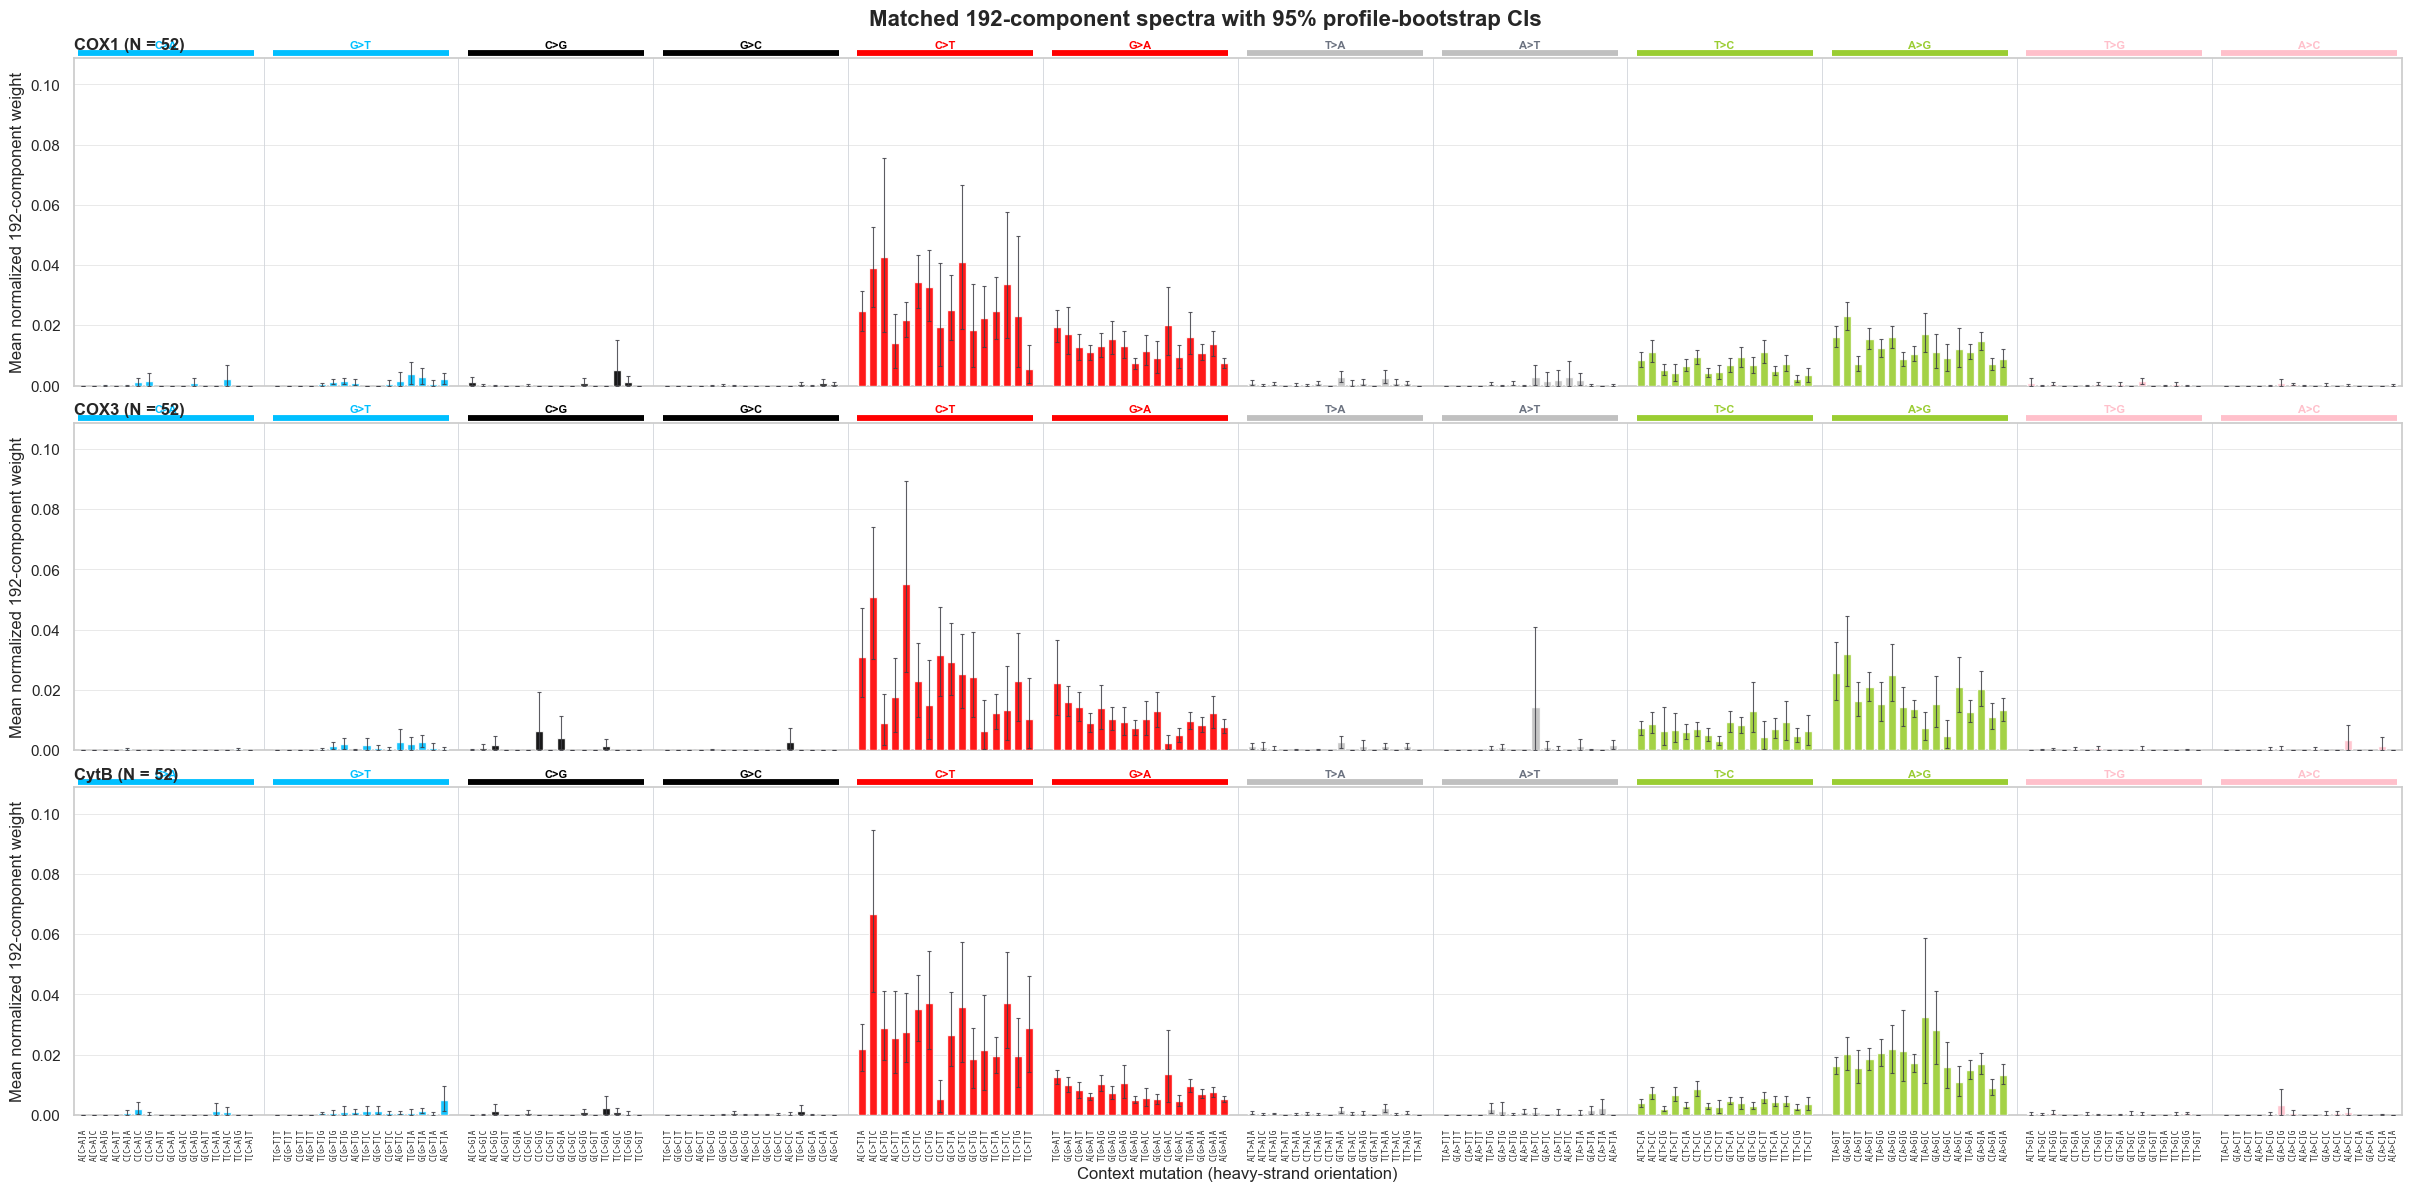

In [5]:
full_summary = summarize_context_components(
    matched,
    genes=GENES,
    value_col="MutSpec",
    weighting="species",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
full_summary.to_csv(DATA_DIR / "context192_mean_spectrum.csv", index=False)

fig, axes = plot_context192_bar_spectra(
    full_summary,
    genes=GENES,
    gene_labels=GENE_LABELS,
    title="Matched 192-component spectra with 95% profile-bootstrap CIs",
)
fig.savefig(FIGURES_DIR / "mean_192_component_spectra.png", dpi=300, bbox_inches="tight")
plt.show()

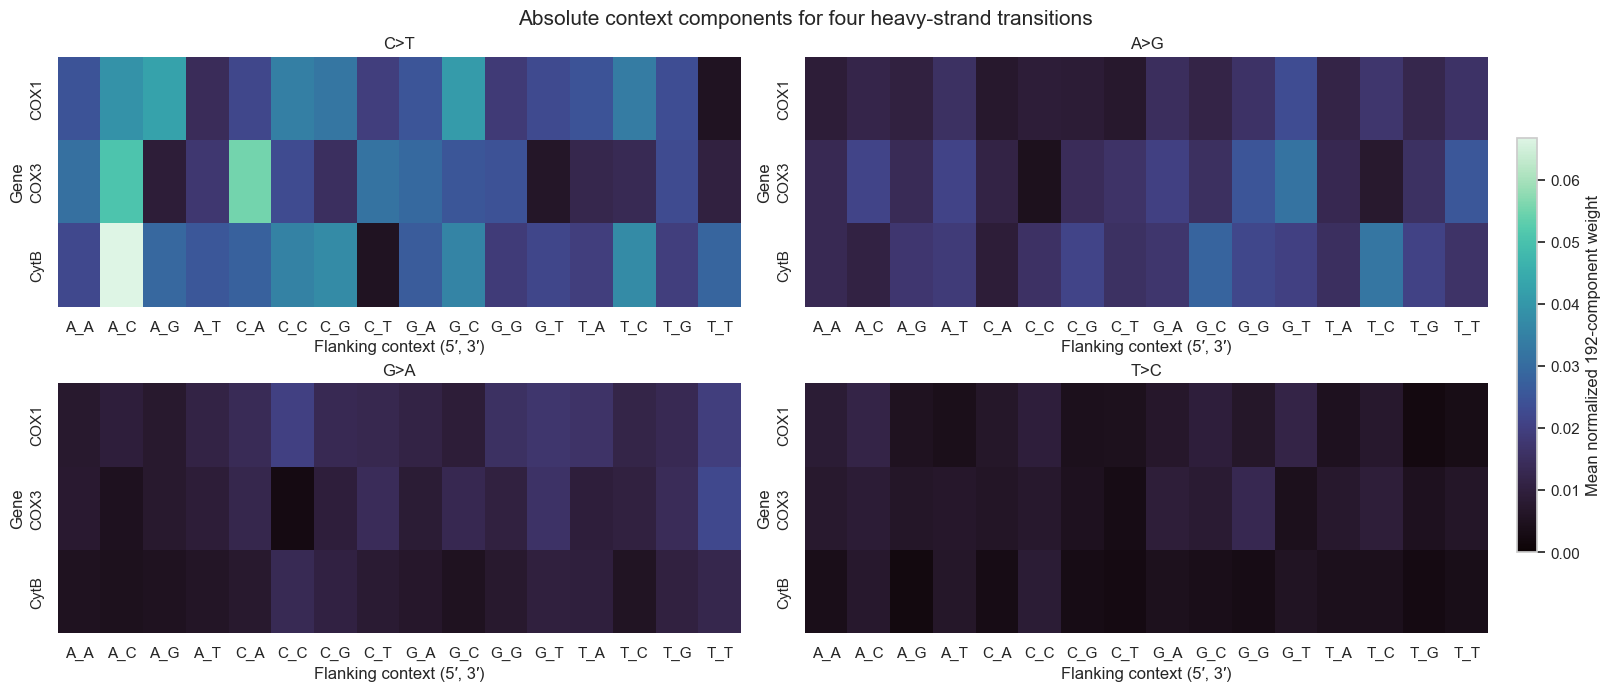

In [6]:
def plot_selected_context_heatmaps(summary, *, colorbar_label, title, cmap="mako"):
    """Plot four central substitutions with a common scale across panels."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 6.8), constrained_layout=True)
    axes = axes.ravel()
    vmax = summary["estimate"].max()
    for axis, substitution in zip(axes, SELECTED_SUBSTITUTIONS):
        matrix = (
            summary.loc[summary["CentralSubstitution"].eq(substitution)]
            .pivot(index="Gene", columns="FlankingContext", values="estimate")
            .reindex(index=GENES, columns=CONTEXT_ORDER)
            .rename(index=GENE_LABELS)
        )
        sns.heatmap(matrix, ax=axis, cmap=cmap, vmin=0, vmax=vmax, cbar=False)
        axis.set_title(substitution)
        axis.set_xlabel("Flanking context (5′, 3′)")
        axis.set_ylabel("Gene")
    colorbar = fig.colorbar(axes[-1].collections[0], ax=list(axes), shrink=0.72, pad=0.02)
    colorbar.set_label(colorbar_label)
    fig.suptitle(title, fontsize=15)
    return fig


selected_mutspec_summary = summarize_context_components(
    matched,
    genes=GENES,
    central_substitutions=SELECTED_SUBSTITUTIONS,
    value_col="MutSpec",
    weighting="species",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
selected_mutspec_summary.to_csv(
    DATA_DIR / "transition_context_mutspec_summary.csv", index=False
)
absolute_fig = plot_selected_context_heatmaps(
    selected_mutspec_summary,
    colorbar_label="Mean normalized 192-component weight",
    title="Absolute context components for four heavy-strand transitions",
)
absolute_fig.savefig(
    FIGURES_DIR / "transition_context_mutspec_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

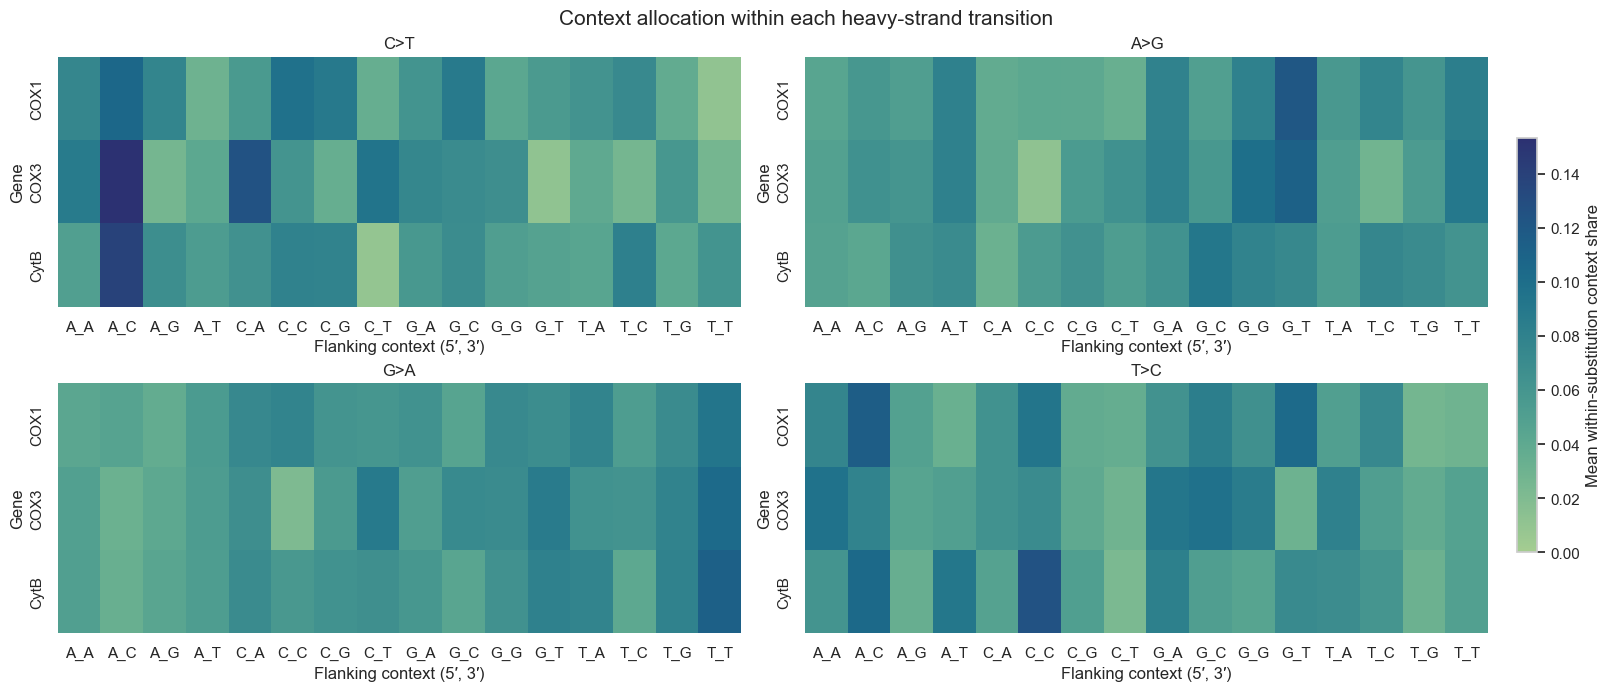

In [7]:
with_context_shares = calculate_within_substitution_shares(
    matched,
    value_col="MutSpec",
    output_col="WithinSubstitutionShare",
    zero_total="nan",
)
share_summary = summarize_context_components(
    with_context_shares,
    genes=GENES,
    central_substitutions=SELECTED_SUBSTITUTIONS,
    value_col="WithinSubstitutionShare",
    weighting="species",
    require_complete_profiles=False,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
share_summary.to_csv(DATA_DIR / "transition_context_share_summary.csv", index=False)
share_fig = plot_selected_context_heatmaps(
    share_summary,
    colorbar_label="Mean within-substitution context share",
    title="Context allocation within each heavy-strand transition",
    cmap="crest",
)
share_fig.savefig(
    FIGURES_DIR / "transition_context_share_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [8]:
# Sensitivity only: gate on a positive expected opportunity before division.
# Missing Observed values represent zero observed events in the source derivation.
oe_rows = matched.loc[
    matched["Expected"].gt(0)
    & matched["CentralSubstitution"].isin(SELECTED_SUBSTITUTIONS)
].copy()
oe_rows["ObservedOverExpected"] = (
    oe_rows["Observed"].fillna(0) / oe_rows["Expected"]
)
assert np.isfinite(oe_rows["ObservedOverExpected"]).all()
oe_summary = summarize_context_components(
    oe_rows,
    genes=GENES,
    central_substitutions=SELECTED_SUBSTITUTIONS,
    value_col="ObservedOverExpected",
    weighting="species",
    require_complete_profiles=False,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
oe_summary.to_csv(DATA_DIR / "transition_context_oe_sensitivity.csv", index=False)
print(
    "Observed/Expected sensitivity uses only Expected > 0 rows; "
    "component-specific species counts therefore vary."
)
display(
    oe_summary.groupby("CentralSubstitution")["n_species"]
    .agg(["min", "median", "max"])
    .astype({"min": int, "max": int})
)

Observed/Expected sensitivity uses only Expected > 0 rows; component-specific species counts therefore vary.


,min,median,max
CentralSubstitution,,,
A>G,33,52.0,52
C>T,20,44.0,52
G>A,37,52.0,52
T>C,49,52.0,52


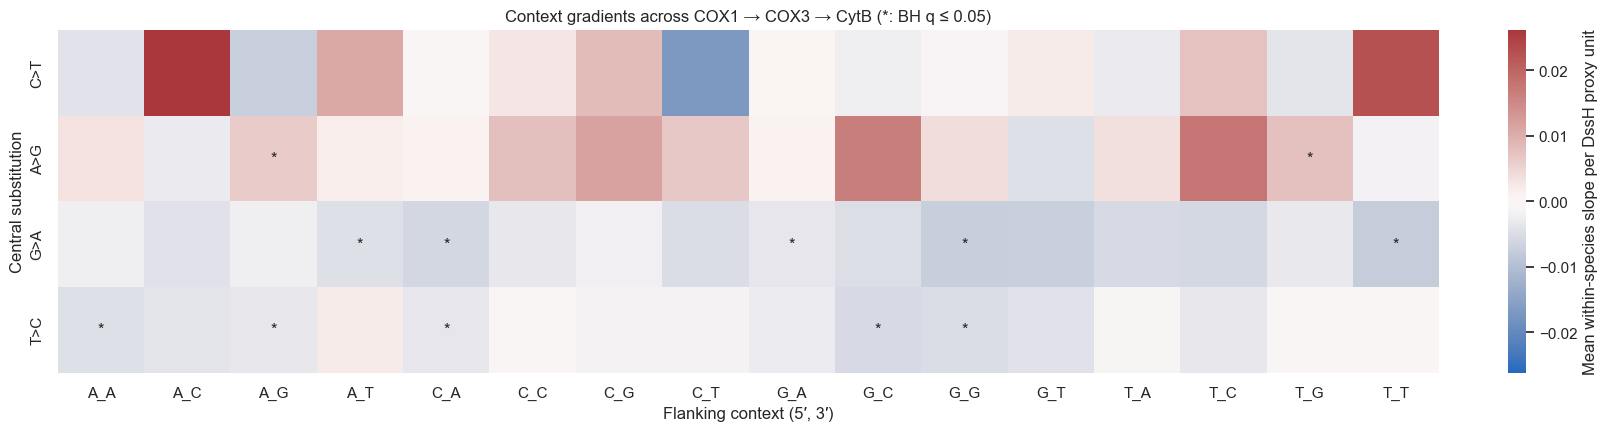

Contexts passing BH q <= 0.05 in both normalized views


,Mut,mean_slope_per_proxy_unit,within_share_mean_slope,fdr_bh_q,within_share_fdr_bh_q


In [9]:
species_slopes = summarize_context_tsss_slopes(
    matched,
    gene_metadata,
    genes=GENES,
    central_substitutions=SELECTED_SUBSTITUTIONS,
    value_col="MutSpec",
    tsss_col="dssh_proxy",
    weighting="species",
    class_col="Class",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
within_share_slopes = summarize_context_tsss_slopes(
    with_context_shares,
    gene_metadata,
    genes=GENES,
    central_substitutions=SELECTED_SUBSTITUTIONS,
    value_col="WithinSubstitutionShare",
    tsss_col="dssh_proxy",
    weighting="species",
    class_col="Class",
    require_complete_profiles=False,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
species_slopes.to_csv(DATA_DIR / "context_tsss_slopes_species_weighted.csv", index=False)
within_share_slopes.to_csv(
    DATA_DIR / "context_tsss_slopes_within_substitution_share.csv", index=False
)

within_for_merge = within_share_slopes[[
    "Mut", "mean_slope_per_proxy_unit", "fdr_bh_q"
]].rename(
    columns={
        "mean_slope_per_proxy_unit": "within_share_mean_slope",
        "fdr_bh_q": "within_share_fdr_bh_q",
    }
)
slope_sensitivity = species_slopes.merge(
    within_for_merge, on="Mut", how="left", validate="one_to_one"
)
slope_sensitivity.to_csv(DATA_DIR / "context_tsss_slope_sensitivity.csv", index=False)

slope_matrix = (
    species_slopes.pivot(
        index="CentralSubstitution",
        columns="FlankingContext",
        values="mean_slope_per_proxy_unit",
    )
    .reindex(index=SELECTED_SUBSTITUTIONS, columns=CONTEXT_ORDER)
)
q_column = next(
    (
        name
        for name in ("fdr_bh_q", "q_value", "q_value_bh", "fdr_q_value")
        if name in species_slopes
    ),
    None,
)
annotations = None
if q_column is not None:
    annotations = (
        species_slopes.assign(marker=lambda frame: np.where(frame[q_column].le(0.05), "*", ""))
        .pivot(index="CentralSubstitution", columns="FlankingContext", values="marker")
        .reindex(index=SELECTED_SUBSTITUTIONS, columns=CONTEXT_ORDER)
    )
limit = np.nanmax(np.abs(slope_matrix.to_numpy()))
fig, axis = plt.subplots(figsize=(16, 4.2), constrained_layout=True)
sns.heatmap(
    slope_matrix,
    ax=axis,
    cmap="vlag",
    center=0,
    vmin=-limit,
    vmax=limit,
    annot=annotations,
    fmt="",
    cbar_kws={"label": "Mean within-species slope per DssH proxy unit"},
)
axis.set_xlabel("Flanking context (5′, 3′)")
axis.set_ylabel("Central substitution")
axis.set_title(
    "Context gradients across COX1 → COX3 → CytB"
    + (" (*: BH q ≤ 0.05)" if q_column is not None else "")
)
fig.savefig(
    FIGURES_DIR / "transition_context_tsss_slopes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

robust_contexts = slope_sensitivity.loc[
    slope_sensitivity["fdr_bh_q"].le(0.05)
    & slope_sensitivity["within_share_fdr_bh_q"].le(0.05)
    & (
        np.sign(slope_sensitivity["mean_slope_per_proxy_unit"])
        == np.sign(slope_sensitivity["within_share_mean_slope"])
    ),
    ["Mut", "mean_slope_per_proxy_unit", "within_share_mean_slope",
     "fdr_bh_q", "within_share_fdr_bh_q"],
]
print("Contexts passing BH q <= 0.05 in both normalized views")
display(robust_contexts.round(4))

## Interpretation limits

These are exploratory context patterns. The 52 mammalian species are phylogenetically non-independent and unevenly sampled among clades. Each slope is determined by three genes, so gene identity, selection, codon composition, genomic position, and replication exposure remain confounded. The fixed human-rCRS coordinates are not species-specific replication measurements. Finally, `MutSpec` is compositional, within-substitution shares intentionally remove differences in total substitution abundance, and `Observed / Expected` is a sparse opportunity-normalized burden rather than a mutation rate.